In [1]:
from pathlib import Path

RAW = Path("../data/raw")
for p in sorted(RAW.rglob("*")):
    if p.is_file():
        print(f"{p.stat().st_size / 1e6:9.2f} MB  {p.relative_to(RAW)}")

     0.00 MB  .gitkeep
     7.39 MB  5EnvSensor_MayToDec2024_180kRows.zip
    84.86 MB  5occupancySensor_MayToDec2024_9MRows.zip
   122.77 MB  Example Data (Do not use)\Detailed_14_07_26 - 17_07_26.csv
     0.23 MB  Example Data (Do not use)\Env_data_MSI_Lab - 30-07-2025_19-12-2025.csv
     1.06 MB  Example Data (Do not use)\Map_XY.png
   216.21 MB  Example Data (Do not use)\PMV_07_25 - 04_26.csv
     0.02 MB  Sensor ID and Locations.xlsx


In [11]:
import pandas as pd

locations = pd.read_excel("../data/raw/Sensor ID and Locations.xlsx", dtype={"ID": str})
print(locations.shape)
locations.head(10)

(78, 6)


,Building,Floor/Room,Area,Physical Label,Sensor,ID
0,60,1-PS01,Corridor,ES1104,Env,6012003000486
1,69,1-PS02,Breakout,ES2113,Env,6012003000882
2,60,1.40,Board Room,ES1102,Env,6012003000462
3,60,1.41,Open Office,ES1110,Env,6012003000424
4,60,1.41A,Focus Room 1,ES1101,Env,6012003000448
5,60,1.42,Startup Workshop,ES1103,Env,6012003000479
6,60,1.43,Startup,ES1105,Env,6012003000493
7,60,1.45,Meeting Room,ES1106,Env,6012003000509
8,60,1.47,Corridor,ES1107,Env,6012003000516
9,60,1.49,Workshop,ES1108,Env,6012003000530


In [12]:
import pandas as pd

df = pd.read_excel("../data/raw/Sensor ID and Locations.xlsx")

In [13]:
df.head()

,Building,Floor/Room,Area,Physical Label,Sensor,ID
0,60,1-PS01,Corridor,ES1104,Env,6012003000486
1,69,1-PS02,Breakout,ES2113,Env,6012003000882
2,60,1.40,Board Room,ES1102,Env,6012003000462
3,60,1.41,Open Office,ES1110,Env,6012003000424
4,60,1.41A,Focus Room 1,ES1101,Env,6012003000448


In [14]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 78 entries, 0 to 77
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   Building        78 non-null     int64
 1   Floor/Room      78 non-null     str  
 2   Area            78 non-null     str  
 3   Physical Label  78 non-null     str  
 4   Sensor          78 non-null     str  
 5   ID              78 non-null     int64
dtypes: int64(2), str(4)
memory usage: 3.8 KB


In [15]:
df.isna().sum()

Building          0
Floor/Room        0
Area              0
Physical Label    0
Sensor            0
ID                0
dtype: int64

In [16]:
locations["Sensor"].value_counts()

Sensor
Env    78
Name: count, dtype: int64

In [17]:
locations["Building"].value_counts()

Building
60    47
69    31
Name: count, dtype: int64

In [18]:
locations["Area"].value_counts()

Area
Lab                    8
Workshop               7
Corridor               4
Startup                4
Meeting Room           3
Motorsport             2
Motorsport_upper       2
Compactus_upper        2
Collaboration Area     2
Breakout               1
Board Room             1
Open Office            1
Focus Room 1           1
Startup Workshop       1
Collab Breakout (W)    1
Collab Breakout (E)    1
Open Office (West)     1
Open Office (East)     1
Electrical             1
Corridor (North)       1
Corridor (Comms)       1
Corridor (South)       1
West Entrance          1
Informal Breakout 1    1
Informal Breakout 2    1
Informal Breakout 3    1
Collab Space (West)    1
Collab Space (East)    1
MSM_3D Printers        1
MSM_Demo               1
MSM_CNC                1
MSM_Robot Charging     1
MSM_Central            1
MSM_Control Room       1
Precious Plastic       1
Fabrication 1          1
Fabrication 2          1
Sanding                1
Machining              1
Machining_upper     

In [19]:
locations["ID"].is_unique

False

In [20]:
dups = locations[locations["ID"].duplicated(keep=False)].sort_values("ID")
print(len(dups), "rows share an ID")
dups

2 rows share an ID


,Building,Floor/Room,Area,Physical Label,Sensor,ID
65,69,G.52,Workshop,ES2G14,Env,6012003000691
75,69,G.61,East Entrance,ES2G01,Env,6012003000691


In [21]:
locations["Physical Label"].is_unique

True

In [23]:
import zipfile
from pathlib import Path

# Find every zip in raw and show sizes, so you can tell the large one from the empty one
for z in Path("../data/raw").rglob("*.zip"):
    print(f"{z.stat().st_size / 1e6:9.1f} MB  {z}")

      7.4 MB  ..\data\raw\5EnvSensor_MayToDec2024_180kRows.zip
     84.9 MB  ..\data\raw\5occupancySensor_MayToDec2024_9MRows.zip


In [25]:
zip_path = Path("../data/raw/5occupancySensor_MayToDec2024_9MRows.zip")

with zipfile.ZipFile(zip_path) as z:
    infos = z.infolist()
    print(len(infos), "entries")
    print(f"{sum(i.file_size for i in infos) / 1e9:.2f} GB uncompressed")
    for i in infos[:25]:
        print(f"{i.file_size / 1e6:9.2f} MB  {i.filename}")

1 entries
1.61 GB uncompressed
  1605.04 MB  5occupancySensor_MayToDec2024_9MRows.csv


In [26]:
import pandas as pd

csv_name = "5occupancySensor_MayToDec2024_9MRows.csv"
with zipfile.ZipFile(zip_path) as z:
    with z.open(csv_name) as f:
        sample = pd.read_csv(f, nrows=1000)

sample.info()
sample.head(10)

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                     Non-Null Count  Dtype
---  ------                     --------------  -----
 0   id                         1000 non-null   int64
 1   deviceid                   1000 non-null   str  
 2   floorspaceid               1000 non-null   str  
 3   occupancystatus            1000 non-null   str  
 4   headcount                  1000 non-null   int64
 5   collecteddate              1000 non-null   str  
 6   occupancystatuschangedate  1000 non-null   str  
 7   previousoccupancystatus    1000 non-null   str  
dtypes: int64(2), str(6)
memory usage: 62.6 KB


,id,deviceid,floorspaceid,occupancystatus,headcount,collecteddate,occupancystatuschangedate,previousoccupancystatus
0,136043,56923747-b390-4f2a-8930-808429132266,941f0352-bb69-47d0-a9c5-ac29eb4f7319,CurrentlyOccupied,1,2023-11-24 00:36:52+11,2023-11-24 00:36:52+11,NotOccupied
1,136048,56923747-b390-4f2a-8930-808429132266,941f0352-bb69-47d0-a9c5-ac29eb4f7319,RecentlyOccupied,0,2023-11-24 00:37:32+11,2023-11-24 00:37:32+11,CurrentlyOccupied
2,136050,56923747-b390-4f2a-8930-808429132266,0f3f37f8-0335-41e0-ae87-a1d677dfc7d7,CurrentlyOccupied,1,2023-11-24 00:37:32+11,2023-11-24 00:37:32+11,NotOccupied
3,136052,56923747-b390-4f2a-8930-808429132266,941f0352-bb69-47d0-a9c5-ac29eb4f7319,NotOccupied,0,2023-11-24 00:37:52+11,2023-11-24 00:37:52+11,RecentlyOccupied
4,136053,56923747-b390-4f2a-8930-808429132266,0f3f37f8-0335-41e0-ae87-a1d677dfc7d7,RecentlyOccupied,0,2023-11-24 00:37:52+11,2023-11-24 00:37:52+11,CurrentlyOccupied
5,136058,56923747-b390-4f2a-8930-808429132266,0f3f37f8-0335-41e0-ae87-a1d677dfc7d7,NotOccupied,0,2023-11-24 00:38:32+11,2023-11-24 00:38:32+11,RecentlyOccupied
6,136067,56923747-b390-4f2a-8930-808429132266,941f0352-bb69-47d0-a9c5-ac29eb4f7319,CurrentlyOccupied,1,2023-11-24 00:40:52+11,2023-11-24 00:40:52+11,NotOccupied
7,136072,56923747-b390-4f2a-8930-808429132266,941f0352-bb69-47d0-a9c5-ac29eb4f7319,RecentlyOccupied,0,2023-11-24 00:41:32+11,2023-11-24 00:41:32+11,CurrentlyOccupied
8,136075,56923747-b390-4f2a-8930-808429132266,0f3f37f8-0335-41e0-ae87-a1d677dfc7d7,CurrentlyOccupied,1,2023-11-24 00:41:32+11,2023-11-24 00:41:32+11,NotOccupied
9,136079,56923747-b390-4f2a-8930-808429132266,941f0352-bb69-47d0-a9c5-ac29eb4f7319,NotOccupied,0,2023-11-24 00:41:52+11,2023-11-24 00:41:52+11,RecentlyOccupied


In [27]:
from pathlib import Path

for z in sorted(Path("../data/raw").rglob("*.zip")):
    print(f"{z.stat().st_size / 1e6:9.1f} MB  {z}")

      7.4 MB  ..\data\raw\5EnvSensor_MayToDec2024_180kRows.zip
     84.9 MB  ..\data\raw\5occupancySensor_MayToDec2024_9MRows.zip


In [28]:
import zipfile

zip2 = Path("../data/raw/5EnvSensor_MayToDec2024_180kRows.zip")

with zipfile.ZipFile(zip2) as z:
    infos = z.infolist()
    print(len(infos), "entries")
    print(f"{sum(i.file_size for i in infos) / 1e9:.2f} GB uncompressed")
    for i in infos[:30]:
        print(f"{i.file_size / 1e6:9.2f} MB  {i.filename}")

1 entries
0.35 GB uncompressed
   352.88 MB  5EnvSensor_MayToDec2024_180kRows.csv


In [30]:
import pandas as pd
import zipfile

zip2 = Path("../data/raw/5EnvSensor_MayToDec2024_180kRows.zip")   # same path you used for the listing
csv2 = "5EnvSensor_MayToDec2024_180kRows.csv"

with zipfile.ZipFile(zip2) as z:
    with z.open(csv2) as f:
        env_sample = pd.read_csv(f, nrows=1000)

print(env_sample.shape)
print(env_sample.columns.tolist())
env_sample.head(5)

(1000, 8)
['id', 'sensorid', 'devicetype', 'jsondata', 'status', 'processing_errors', 'createdate', 'processdate']


,id,sensorid,devicetype,jsondata,status,processing_errors,createdate,processdate
0,2,6012002000241,env,"[{""values"": [{""time"": 1702273965, ""value"": 4.1...",Processed,NaN,2024-02-29 03:11:58.210358+11,2024-02-29 03:11:58.210358+11
1,4,6012002000241,env,"[{""values"": [{""time"": 1702273965, ""value"": 4.1...",Processed,NaN,2024-02-29 17:09:08.833822+11,2024-02-29 17:09:08.833822+11
2,5,6012002000326,env,"[{""values"": [{""time"": 1702270857, ""value"": 4.1...",Processed,NaN,2024-02-29 17:09:12.444245+11,2024-02-29 17:09:12.444245+11
3,16,6012002000777,env,"[{""values"": [{""time"": 1683326565, ""value"": 4.1...",Processed,NaN,2024-02-29 17:10:24.443407+11,2024-02-29 17:10:24.443407+11
4,24,6012002000869,env,"[{""values"": [{""time"": 1709186696, ""value"": 4.1...",Processed,NaN,2024-02-29 17:11:11.348578+11,2024-02-29 17:11:11.348578+11


In [31]:
import json

print(env_sample.loc[0, "jsondata"][:1500])

parsed = json.loads(env_sample.loc[0, "jsondata"])
print(type(parsed), len(parsed))
print(parsed[0].keys())

[{"values": [{"time": 1702273965, "value": 4.1875}], "variable": {"id": 66, "name": "Battery", "unit": "V", "source": 0, "structure": 32834}}, {"values": [{"time": 1702273965, "value": 603}], "variable": {"id": 67, "name": "Carbon dioxide", "unit": "ppm", "source": 0, "structure": 32835}}, {"values": [{"time": 1702273965, "value": 66}], "variable": {"id": 72, "name": "Humidity", "unit": "HR%", "source": 0, "structure": 32840}}, {"values": [{"time": 1702273965, "value": 6}], "variable": {"id": 70, "name": "Formaldehyde", "unit": "µg/m3", "source": 0, "structure": 32847}}, {"values": [{"time": 1702273965, "value": 1011}], "variable": {"id": 80, "name": "Pressure", "unit": "mb", "source": 0, "structure": 32848}}, {"values": [{"time": 1702273965, "value": 23.8}], "variable": {"id": 84, "name": "Temperature", "unit": "°C", "source": 0, "structure": 32852}}, {"values": [{"time": 1702273965, "value": 14}], "variable": {"id": 99, "name": "Light Volatile Organic Compounds", "unit": "ppb", "sour

In [36]:
%%time
import zipfile
from pathlib import Path
import pandas as pd
import pyarrow as pa
import pyarrow.parquet as pq
from occupancy.loading import flatten_env_chunk

zip2 = Path("../data/raw/5EnvSensor_MayToDec2024_180kRows.zip")
csv2 = "5EnvSensor_MayToDec2024_180kRows.csv"
out_path = "../data/processed/env_long.parquet"
writer = None

with zipfile.ZipFile(zip2) as z, z.open(csv2) as f:
    for chunk in pd.read_csv(f, chunksize=20_000, usecols=["sensorid", "jsondata"]):
        flat = flatten_env_chunk(chunk)
        table = pa.Table.from_pandas(flat, preserve_index=False)
        if writer is None:
            writer = pq.ParquetWriter(out_path, table.schema)
        writer.write_table(table)
writer.close()

C:\Users\Elitebook\3001-OCCUPANCY-PROJECT\src\occupancy\loading.py:36: UserWarning: Skipped 13933 rows with missing or invalid jsondata
  warnings.warn(f"Skipped {n_bad} rows with missing or invalid jsondata")
C:\Users\Elitebook\3001-OCCUPANCY-PROJECT\src\occupancy\loading.py:36: UserWarning: Skipped 20000 rows with missing or invalid jsondata
  warnings.warn(f"Skipped {n_bad} rows with missing or invalid jsondata")
C:\Users\Elitebook\3001-OCCUPANCY-PROJECT\src\occupancy\loading.py:36: UserWarning: Skipped 20000 rows with missing or invalid jsondata
  warnings.warn(f"Skipped {n_bad} rows with missing or invalid jsondata")
C:\Users\Elitebook\3001-OCCUPANCY-PROJECT\src\occupancy\loading.py:36: UserWarning: Skipped 20000 rows with missing or invalid jsondata
  warnings.warn(f"Skipped {n_bad} rows with missing or invalid jsondata")
C:\Users\Elitebook\3001-OCCUPANCY-PROJECT\src\occupancy\loading.py:36: UserWarning: Skipped 20000 rows with missing or invalid jsondata
  warnings.warn(f"Skippe

CPU times: total: 19 s
Wall time: 19.1 s


C:\Users\Elitebook\3001-OCCUPANCY-PROJECT\src\occupancy\loading.py:36: UserWarning: Skipped 19447 rows with missing or invalid jsondata
  warnings.warn(f"Skipped {n_bad} rows with missing or invalid jsondata")


In [37]:
import json
from collections import Counter

zip2 = next(Path("../data/raw").rglob("5EnvSensor_MayToDec2024_180kRows.zip"))
csv2 = "5EnvSensor_MayToDec2024_180kRows.csv"

# read a later chunk (the 3rd block of 20,000 rows) with all columns
with zipfile.ZipFile(zip2) as z, z.open(csv2) as f:
    reader = pd.read_csv(f, chunksize=20_000)
    for i, chunk in enumerate(reader):
        if i == 2:
            break

print(chunk["devicetype"].value_counts(dropna=False))
print(chunk["status"].value_counts(dropna=False))
print(chunk["processing_errors"].notna().sum(), "rows with processing_errors")
print(chunk["jsondata"].isna().sum(), "rows with missing jsondata")

errors = Counter()
examples = {}
for raw in chunk["jsondata"]:
    try:
        payload = json.loads(raw)
        for var in payload:
            var["variable"]["name"]
            var["variable"]["unit"]
            for v in var["values"]:
                v["time"], v["value"]
    except Exception as e:
        key = type(e).__name__
        errors[key] += 1
        examples.setdefault(key, raw)

print(errors)
for k, v in examples.items():
    print("\n", k, ":", str(v)[:600])

devicetype
env    20000
Name: count, dtype: int64
status
Processed    20000
Name: count, dtype: int64
0 rows with processing_errors
0 rows with missing jsondata
Counter()


In [38]:
import json
from collections import Counter

with zipfile.ZipFile(zip2) as z, z.open(csv2) as f:
    for i, chunk in enumerate(pd.read_csv(f, chunksize=20_000)):
        errs, ex = Counter(), {}
        for raw in chunk["jsondata"]:
            try:
                payload = json.loads(raw)
                for var in payload:
                    var["variable"]["name"]; var["variable"]["unit"]
                    for v in var["values"]:
                        v["time"]; v["value"]
            except Exception as e:
                k = type(e).__name__
                errs[k] += 1
                ex.setdefault(k, str(raw)[:300])
        print(i, len(chunk), "missing:", chunk["jsondata"].isna().sum(), dict(errs))
        for k, s in ex.items():
            print("    ", k, "->", s)

0 20000 missing: 0 {}
1 20000 missing: 0 {}
2 20000 missing: 0 {}
3 20000 missing: 0 {'KeyError': 13933}
     KeyError -> [{"values": [{"time": 1702271273, "value": 4.1875}], "variable": {"id": 66, "name": "Battery", "unit": "V", "source": 0, "structure": 32834}}, {"values": [{"time": 1702271273, "value": 666}], "variable": {"id": 67, "name": "Carbon dioxide", "unit": "ppm", "source": 0, "structure": 32835}}, {"values"
4 20000 missing: 0 {'KeyError': 20000}
     KeyError -> [{"values": [{"time": 1702273965, "value": 4.1875}], "variable": {"id": 66, "name": "Battery", "unit": "V", "source": 0, "structure": 32834}}, {"values": [{"time": 1702273965, "value": 603}], "variable": {"id": 67, "name": "Carbon dioxide", "unit": "ppm", "source": 0, "structure": 32835}}, {"values"
5 20000 missing: 0 {'KeyError': 20000}
     KeyError -> [{"values": [{"time": 1702270857, "value": 4.1875}], "variable": {"id": 66, "name": "Battery", "unit": "V", "source": 0, "structure": 32834}}, {"values": [{"time": 

In [39]:
from collections import Counter
import json

with zipfile.ZipFile(zip2) as z, z.open(csv2) as f:
    for i, chunk in enumerate(pd.read_csv(f, chunksize=20_000)):
        if i == 4:
            break

def find_problems(payload):
    out = []
    for var in payload:
        if "variable" not in var:
            out.append(("no 'variable' key", str(var)[:200])); continue
        for k in ("name", "unit"):
            if k not in var["variable"]:
                out.append((f"variable missing '{k}'", str(var["variable"])))
        if "values" not in var:
            out.append(("no 'values' key", str(var["variable"]))); continue
        for v in var["values"]:
            for k in ("time", "value"):
                if k not in v:
                    out.append((f"reading missing '{k}'", str(var["variable"].get("name"))))
    return out

counts, examples = Counter(), {}
for raw in chunk["jsondata"].head(2000):
    for label, detail in find_problems(json.loads(raw)):
        counts[label] += 1
        examples.setdefault(label, detail)

print(counts)
for k, v in examples.items():
    print(k, "->", v)

# also list the variable names present in a failing row
print([v["variable"].get("name") for v in json.loads(chunk["jsondata"].iloc[0])])

Counter({"reading missing 'value'": 2000})
reading missing 'value' -> Formaldehyde
['Battery', 'Carbon dioxide', 'Humidity', 'Formaldehyde', 'Pressure', 'Temperature', 'Light Volatile Organic Compounds', 'Particulate matter 1', 'Particulate matter 4', 'Particulate matter 2.5', 'Particulate matter 10']


In [40]:
row = json.loads(chunk["jsondata"].iloc[0])
print([v for v in row if v["variable"]["name"] == "Formaldehyde"])

[{'values': [{'time': 1702273965}], 'variable': {'id': 70, 'name': 'Formaldehyde', 'unit': 'µg/m3', 'source': 0, 'structure': 32847}}]


In [1]:
%%time
from collections import Counter
import zipfile
from pathlib import Path
import pandas as pd
import pyarrow as pa
import pyarrow.parquet as pq
from occupancy.loading import flatten_env_chunk

zip2 = next(Path("../data/raw").rglob("5EnvSensor_MayToDec2024_180kRows.zip"))
csv2 = "5EnvSensor_MayToDec2024_180kRows.csv"
out_path = "../data/processed/env_long.parquet"
problems, n_messages, writer = Counter(), 0, None

with zipfile.ZipFile(zip2) as z, z.open(csv2) as f:
    for chunk in pd.read_csv(f, chunksize=20_000, usecols=["sensorid", "jsondata"]):
        n_messages += len(chunk)
        flat = flatten_env_chunk(chunk, problems)
        table = pa.Table.from_pandas(flat, preserve_index=False)
        if writer is None:
            writer = pq.ParquetWriter(out_path, table.schema)
        writer.write_table(table)
writer.close()

print(n_messages, "messages read")
print(dict(problems))

179447 messages read
{'reading missing time/value: Formaldehyde': 113380}
CPU times: total: 25.9 s
Wall time: 26.6 s


In [2]:
env = pd.read_parquet("../data/processed/env_long.parquet")
print(env.shape, env["time"].min(), env["time"].max())
print(env.groupby("variable")["value"].count())
print(env["sensorid"].nunique(), "sensors")

(1824135, 5) 2023-05-05 22:42:45+00:00 2026-04-22 13:12:41+00:00
variable
Battery                             179447
Carbon dioxide                      179447
Formaldehyde                         66067
Humidity                            179447
Light Volatile Organic Compounds    149881
Particulate matter 1                177738
Particulate matter 10               177738
Particulate matter 2.5              177738
Particulate matter 4                177738
Pressure                            179447
Temperature                         179447
Name: value, dtype: int64
5 sensors


In [3]:
by_sensor = env.groupby("sensorid").agg(
    readings=("value", "size"),
    first=("time", "min"),
    last=("time", "max"),
)
print(by_sensor)

form = env[env["variable"] == "Formaldehyde"].groupby("sensorid")["time"].agg(["count", "max"])
print(form)

ids_loc = set(locations["ID"].astype(str))
print(set(env["sensorid"]) & ids_loc, "matching IDs in the locations file")

               readings                     first                      last
sensorid                                                                   
6012002000227    221430 2023-12-11 05:07:53+00:00 2023-12-11 05:07:53+00:00
6012002000241    575295 2023-12-11 05:52:45+00:00 2025-05-19 13:08:04+00:00
6012002000326    598034 2023-12-11 05:00:57+00:00 2026-04-22 13:12:41+00:00
6012002000777    120186 2023-05-05 22:42:45+00:00 2023-05-05 22:42:45+00:00
6012002000869    309190 2024-02-29 06:04:56+00:00 2024-06-13 17:45:44+00:00
               count                       max
sensorid                                      
6012002000227   7800 2023-12-11 05:07:53+00:00
6012002000241  15781 2023-12-11 05:52:45+00:00
6012002000326  15780 2023-12-11 05:00:57+00:00
6012002000777  10926 2023-05-05 22:42:45+00:00
6012002000869  15780 2024-06-13 17:45:44+00:00


NameError: name 'locations' is not defined

In [4]:
import pandas as pd
from pathlib import Path

xlsx_files = list(Path("../data/raw").rglob("*.xlsx"))
print(xlsx_files)   # check this is the sensor-locations file
locations = pd.read_excel(xlsx_files[0], dtype={"ID": str})

ids_loc = set(locations["ID"])
ids_env = set(env["sensorid"])
print(sorted(ids_env))
print(ids_env & ids_loc, "matching IDs in the locations file")

[WindowsPath('../data/raw/Sensor ID and Locations.xlsx')]
['6012002000227', '6012002000241', '6012002000326', '6012002000777', '6012002000869']
{'6012002000869'} matching IDs in the locations file


In [5]:
print(locations[locations["ID"] == "6012002000869"])

print(locations[locations["ID"].str.startswith("6012002")])

# are the other four IDs close to anything? compare on the last 6 digits
env_tail = {i[-6:]: i for i in ids_env}
print(locations[locations["ID"].str[-6:].isin(env_tail)])

    Building Floor/Room             Area Physical Label Sensor             ID
60        60       G.38  Compactus_upper         EMS107    Env  6012002000869
    Building Floor/Room                Area Physical Label Sensor  \
26        60     G-PS01          Electrical         EMS006    Env   
27        60     G-PS01          Motorsport         EMS010    Env   
44        60      G.33B    Motorsport_upper         EMS109    Env   
45        60      G.33C          Motorsport         EMS012    Env   
46        60      G.33C    Motorsport_upper         EMS104    Env   
47        60      G.33D    Precious Plastic         EMS004    Env   
48        60      G.34A       Fabrication 1         EMS001    Env   
49        60      G.34A       Fabrication 2         EMS007    Env   
50        60      G.34B             Sanding         EMS005    Env   
51        60      G.35A           Machining         EMS013    Env   
52        60      G.35A     Machining_upper         EMS103    Env   
53        60    

In [6]:
print(pd.ExcelFile("../data/raw/Sensor ID and Locations.xlsx").sheet_names)

['ENV', 'OCC (Incorrect Data - SpaceFloo']


In [7]:
xl = pd.ExcelFile("../data/raw/Sensor ID and Locations.xlsx")
occ_name = xl.sheet_names[1]
print(occ_name)

occ_map = xl.parse(occ_name, dtype=str)
print(occ_map.shape)
print(occ_map.columns.tolist())
occ_map.head(15)

OCC (Incorrect Data - SpaceFloo
(89, 7)
['Building', 'Floor/Room', 'Area', 'ID', 'Note', 'FloorId', 'SpaceId']


,Building,Floor/Room,Area,ID,Note,FloorId,SpaceId
0,60,1-PS01,NaN,8034-2812-ae89,NaN,94fda9ec-e483-460e-96ce-5767c791c1c1,fe553808-899c-43a3-96f7-f444f41f3046
1,60,1-PS01,NaN,8034-2812-c28f,NaN,94fda9ec-e483-460e-96ce-5767c791c1c1,bd7e25c4-beb5-4d17-9426-859cacfd0f03
2,60,1-PS01,NaN,8034-2812-bfc5,NaN,94fda9ec-e483-460e-96ce-5767c791c1c1,67235649-ade6-43d7-a216-180d6dd8e3c1
3,60,1-PS01,NaN,8034-2812-cc64,NaN,94fda9ec-e483-460e-96ce-5767c791c1c1,7ac9618b-5096-41a1-85d9-2db3541075e6
4,60,1.38,NaN,8034-2812-ecc1,NaN,94fda9ec-e483-460e-96ce-5767c791c1c1,56d7400d-7933-4e4e-9ecc-e5da4c8f991d
5,60,1.39,NaN,missing,Missing Id,94fda9ec-e483-460e-96ce-5767c791c1c1,2387067e-5349-422a-a4f5-08d93ef52a6e
6,60,1.40,NaN,8034-285a-73d4,NaN,94fda9ec-e483-460e-96ce-5767c791c1c1,f1bbb258-eb6b-4711-9523-5799bf87e53b
7,60,1.41,NaN,8034-2812-e179,NaN,94fda9ec-e483-460e-96ce-5767c791c1c1,b8de6aba-795f-4ebc-9f6c-fc7073dd2dc7
8,60,1.41A,NaN,8034-2812-bfb7,NaN,94fda9ec-e483-460e-96ce-5767c791c1c1,02ffc7a7-0dce-4791-a86b-062723514932
9,60,1.41B,NaN,8034-2812-c01f,NaN,94fda9ec-e483-460e-96ce-5767c791c1c1,27bdd98c-e1da-485b-a4df-17ec067ed09a


In [8]:
env_ids = ["6012002000227", "6012002000241", "6012002000326", "6012002000777", "6012002000869"]
uuids = ["941f0352-bb69-47d0-a9c5-ac29eb4f7319",
         "0f3f37f8-0335-41e0-ae87-a1d677dfc7d7",
         "56923747-b390-4f2a-8930-808429132266"]

for name in xl.sheet_names:
    sheet = xl.parse(name, dtype=str)
    text = sheet.astype(str).apply(lambda col: col.str.strip())
    for target in env_ids + uuids:
        hits = text.isin([target]).any(axis=1).sum()
        if hits:
            print(f"{name[:25]!r}: {target} -> {hits} row(s)")

'ENV': 6012002000869 -> 1 row(s)


In [9]:
%%time
import zipfile
from pathlib import Path
import pandas as pd
import pyarrow as pa
import pyarrow.parquet as pq

zip_occ = next(Path("../data/raw").rglob("5occupancySensor_MayToDec2024_9MRows.zip"))
csv_occ = "5occupancySensor_MayToDec2024_9MRows.csv"
out_occ = "../data/processed/occupancy.parquet"
writer, n_rows = None, 0

with zipfile.ZipFile(zip_occ) as z, z.open(csv_occ) as f:
    for chunk in pd.read_csv(f, chunksize=500_000, dtype={"headcount": "int16"}):
        chunk["collecteddate"] = pd.to_datetime(chunk["collecteddate"], utc=True)
        chunk["occupancystatuschangedate"] = pd.to_datetime(
            chunk["occupancystatuschangedate"], utc=True
        )
        n_rows += len(chunk)
        table = pa.Table.from_pandas(chunk, preserve_index=False)
        if writer is None:
            writer = pq.ParquetWriter(out_occ, table.schema)
        writer.write_table(table)
writer.close()
print(n_rows, "rows written")

9091732 rows written
CPU times: total: 2min 48s
Wall time: 2min 48s


In [10]:
import pandas as pd
from pathlib import Path

occ = pd.read_parquet("../data/processed/occupancy.parquet")
print(occ.shape)
print(occ["collecteddate"].min(), "to", occ["collecteddate"].max())
print(occ["deviceid"].nunique(), "devices,", occ["floorspaceid"].nunique(), "spaces")
print(occ["occupancystatus"].value_counts())
print(occ["headcount"].value_counts().head(10))
print(occ["id"].is_unique, occ.isna().sum().sum(), "missing values")

# events per space, and per year-month
print(occ.groupby("floorspaceid").size().describe())
print(occ.groupby(occ["collecteddate"].dt.to_period("M")).size())

# compare against the OCC sheet
xl = pd.ExcelFile("../data/raw/Sensor ID and Locations.xlsx")
occ_map = xl.parse(xl.sheet_names[1], dtype=str)
spaces_in_csv = set(occ["floorspaceid"])
print(len(spaces_in_csv & set(occ_map["SpaceId"].dropna())), "of", len(spaces_in_csv), "floorspaceid values found in SpaceId")
print(len(spaces_in_csv & set(occ_map["FloorId"].dropna())), "found in FloorId")
print(occ_map["Note"].value_counts(dropna=False))
print(occ_map[occ_map["ID"].str.contains(r"\?|missing", na=True)][["Floor/Room", "ID", "Note"]])

(9091732, 8)
2023-11-23 13:36:52+00:00 to 2026-04-22 13:02:38+00:00
1 devices, 5 spaces
occupancystatus
CurrentlyOccupied    8405894
RecentlyOccupied      420133
NotOccupied           265705
Name: count, dtype: int64
headcount
2    2294239
1    1941153
3    1489709
4     919319
0     685838
5     563823
6     352809
7     228009
8     153330
9     106008
Name: count, dtype: int64
True 0 missing values
count    5.000000e+00
mean     1.818346e+06
std      2.855114e+05
min      1.500394e+06
25%      1.551583e+06
50%      1.894871e+06
75%      1.975423e+06
max      2.169461e+06
dtype: float64


C:\Users\Elitebook\AppData\Local\Temp\ipykernel_24948\4061976418.py:14: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  print(occ.groupby(occ["collecteddate"].dt.to_period("M")).size())


collecteddate
2023-11     15133
2023-12     49415
2024-01     31958
2024-02     91331
2024-03    381279
2024-04    356543
2024-05    702321
2024-06    332372
2024-07    525196
2024-08    761191
2024-09    741583
2024-10    703480
2024-11    169534
2024-12    188014
2025-01    107629
2025-02    141809
2025-03    232225
2025-04    212245
2025-05    516511
2025-06    154975
2025-07    247133
2025-08    361997
2025-09    367217
2025-10    367458
2025-11    191228
2025-12    144261
2026-01    193526
2026-02    230568
2026-03    363092
2026-04    210508
Freq: M, dtype: int64
2 of 5 floorspaceid values found in SpaceId
0 found in FloorId
Note
NaN                         82
2.4m (Keenan Lab)            2
smart_infrastructure_lab     2
Missing Id                   1
Not found ID,                1
#REF!                        1
Name: count, dtype: int64
   Floor/Room                 ID        Note
5        1.39            missing  Missing Id
13       1.45  8034-2812-f91a(?)         NaN
18       

In [11]:
# 1. is headcount 0 exactly when the space isn't currently occupied?
print(pd.crosstab(occ["occupancystatus"], occ["headcount"] == 0))
print("max headcount:", occ["headcount"].max())

# 2. what does a row represent?
changed = occ["collecteddate"] == occ["occupancystatuschangedate"]
print(changed.mean(), "of rows are stamped at the moment of a status change")
print((occ["occupancystatus"] == occ["previousoccupancystatus"]).mean(), "of rows repeat the previous status")

# 3. which rooms are the two matched spaces? (compare with G.38, the located env sensor)
matched = spaces_in_csv & set(occ_map["SpaceId"].dropna())
print(occ_map[occ_map["SpaceId"].isin(matched)][["Building", "Floor/Room", "Area", "ID", "Note", "SpaceId"]])
print(occ.groupby("floorspaceid").size())

# 4. gaps between events per space, in seconds
occ = occ.sort_values(["floorspaceid", "collecteddate"])
gap = occ.groupby("floorspaceid")["collecteddate"].diff().dt.total_seconds()
print(gap.groupby(occ["floorspaceid"]).describe())

headcount            False   True 
occupancystatus                   
CurrentlyOccupied  8405894       0
NotOccupied              0  265705
RecentlyOccupied         0  420133
max headcount: 72
0.12164931830370715 of rows are stamped at the moment of a status change
0.0 of rows repeat the previous status
   Building Floor/Room Area              ID               Note  \
60       60       G.20  NaN  8034-2812-bfed                NaN   
61       60       G.20  NaN  8034-285a-c064                NaN   
64       60       G.25  NaN  8034-285a-72f0  2.4m (Keenan Lab)   
65       60       G.25  NaN  8034-2812-6ebd  2.4m (Keenan Lab)   

                                 SpaceId  
60  cca1ac3e-f81f-4ebb-aa2b-8b0bf3e9e53b  
61  cca1ac3e-f81f-4ebb-aa2b-8b0bf3e9e53b  
64  227f1068-9e41-469f-bef0-275f27a0bdba  
65  227f1068-9e41-469f-bef0-275f27a0bdba  
floorspaceid
0f3f37f8-0335-41e0-ae87-a1d677dfc7d7    2169461
227f1068-9e41-469f-bef0-275f27a0bdba    1500394
3e5a14df-4b14-4ea5-bb9d-46577c6dc9c8    

In [12]:
# time until the next event, by the status of the row before the silence
occ["gap_next_s"] = (-occ.groupby("floorspaceid")["collecteddate"].diff(-1)).dt.total_seconds()
print(occ.groupby("occupancystatus")["gap_next_s"].describe(percentiles=[.5, .9, .99, .999]))

# silences longer than a day: when they started and what the last reading said
long = occ[occ["gap_next_s"] > 86400][["floorspaceid", "collecteddate", "occupancystatus", "headcount", "gap_next_s"]]
print(len(long), "silences longer than 1 day")
print(long.sort_values("gap_next_s", ascending=False).head(15))

# headcount distribution per space
print(occ.groupby("floorspaceid")["headcount"].describe(percentiles=[.5, .99]))
print((occ["headcount"] > 30).sum(), "rows with headcount above 30")

# are any ENV-sheet sensors in G.20 or G.25?
print(locations[locations["Floor/Room"].isin(["G.20", "G.25", "G.38"])])

                       count        mean          std  min   50%     90%  \
occupancystatus                                                            
CurrentlyOccupied  8405894.0   12.591706    55.695134  0.0   4.0    30.0   
NotOccupied         265700.0  726.127113  5115.692509  2.0  98.0  1040.0   
RecentlyOccupied    420133.0   22.315091    11.705336  0.0  24.0    30.0   

                        99%      99.9%        max  
occupancystatus                                    
CurrentlyOccupied    136.00    498.000    34264.0  
NotOccupied        13244.02  47565.224  1349782.0  
RecentlyOccupied      40.00     40.000     4586.0  
31 silences longer than 1 day
                                 floorspaceid             collecteddate  \
64544    941f0352-bb69-47d0-a9c5-ac29eb4f7319 2023-12-23 10:07:58+00:00   
64547    0f3f37f8-0335-41e0-ae87-a1d677dfc7d7 2023-12-23 11:22:58+00:00   
8090913  cca1ac3e-f81f-4ebb-aa2b-8b0bf3e9e53b 2025-12-23 18:19:54+00:00   
5031770  0f3f37f8-0335-41e0-a

CPU times: total: 188 ms
Wall time: 211 ms
CPU times: total: 172 ms
Wall time: 166 ms
74911 bins, 0 missing
count    74911.000000
mean         0.346936
std          0.389244
min          0.000000
25%          0.000000
50%          0.151111
75%          0.726667
max          1.000000
Name: mean, dtype: float64


Matplotlib is building the font cache; this may take a moment.


<Axes: >

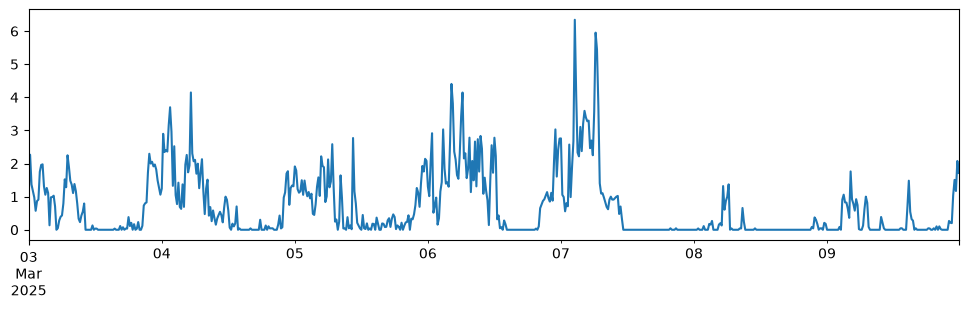

In [13]:
from occupancy.gridding import step_function_to_grid

sid = "227f1068-9e41-469f-bef0-275f27a0bdba"   # G.25 in the (unreliable) OCC sheet
one = occ[occ["floorspaceid"] == sid].sort_values(["collecteddate", "id"])

%time hc = step_function_to_grid(one["collecteddate"], one["headcount"], "15min")
%time occupied = step_function_to_grid(one["collecteddate"], (one["headcount"] > 0), "15min")

print(len(hc), "bins,", hc.isna().sum(), "missing")
print(occupied.describe())
hc.loc["2025-03-03":"2025-03-09"].plot(figsize=(12, 3))

In [14]:
big = occ[occ["headcount"] > 30]
print(big.groupby("floorspaceid").size())
local = big["collecteddate"].dt.tz_convert("Australia/Melbourne")
print(local.dt.date.value_counts().head(10))

floorspaceid
0f3f37f8-0335-41e0-ae87-a1d677dfc7d7      258
227f1068-9e41-469f-bef0-275f27a0bdba      266
3e5a14df-4b14-4ea5-bb9d-46577c6dc9c8      208
cca1ac3e-f81f-4ebb-aa2b-8b0bf3e9e53b    14631
dtype: int64
collecteddate
2025-05-12    4146
2024-08-04    1334
2024-09-11    1289
2025-10-15     992
2026-03-12     982
2026-03-31     905
2024-03-07     884
2025-11-07     830
2026-02-19     740
2024-10-23     676
Name: count, dtype: int64


In [15]:
from occupancy.gridding import step_function_to_grid

grids = {}
for sid, grp in occ.groupby("floorspaceid"):
    grp = grp.sort_values(["collecteddate", "id"])
    hc = step_function_to_grid(grp["collecteddate"], grp["headcount"], "15min")
    grids[sid] = hc

for sid, hc in grids.items():
    print(sid[:8], len(hc), "bins,", hc.isna().sum(), "missing")

0f3f37f8 84573 bins, 0 missing
227f1068 74911 bins, 0 missing
3e5a14df 23415 bins, 0 missing
941f0352 84573 bins, 0 missing
cca1ac3e 74914 bins, 0 missing


In [16]:
import pandas as pd

long = pd.concat(
    [g.rename("headcount").to_frame().assign(space=sid[:8]) for sid, g in grids.items()]
)
long.index.name = "time"
long = long.reset_index()
long.to_parquet("../data/processed/occupancy_15min.parquet")